# Telecom Customer Churn Prediction using Logistic Regression

## Problem Statement

A telecom company wants to identify customers who are likely to leave the company.

The goal is to build a Logistic Regression model that:
- Learns patterns related to customer churn
- Predicts the probability of churn
- Classifies customers as Likely to Churn or Likely to Stay
- Evaluates the model using classification metrics
- Provides business insights for customer retention

## 1. Import Required Libraries

We import the libraries required for data analysis, preprocessing,
Logistic Regression, evaluation, and visualization.

In [22]:
# Import pandas for data manipulation
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import tools for preprocessing numerical and categorical features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Import Pipeline to combine preprocessing and modeling
from sklearn.pipeline import Pipeline

# Import Logistic Regression classification model
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Data Collection

The Telco Customer Churn dataset contains customer demographic,
service, contract, billing, and churn information.

In [23]:
# Load the telecom customer churn dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first five records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Understanding the Dataset

First, we inspect the dataset shape, columns, data types,
and basic information before preprocessing.

In [24]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display all available column names
print("\nColumns:")
print(df.columns.tolist())

# Display data types and non-null information
print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   

## 4. Data Pre-processing

The dataset contains numerical and categorical attributes.

`TotalCharges` is stored as text, so it is converted into a numeric
column. Rows where the conversion produces missing values are removed.

The customer ID is removed because it is only an identifier and does
not provide useful information for predicting churn.

In [25]:
# Convert TotalCharges from text to numeric values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remove rows where TotalCharges could not be converted
df = df.dropna(subset=["TotalCharges"])

# Remove customerID because it is only an identifier
df = df.drop(columns=["customerID"])

# Display the updated dataset shape
print("Shape after preprocessing:", df.shape)

Shape after preprocessing: (7032, 20)


## 5. Feature Selection

The target variable is `Churn`.

Relevant customer attributes such as tenure, monthly charges,
contract type, internet service, support services, payment method,
and demographic information are used as input features.

In [26]:
# Separate input features from the target variable
X = df.drop(columns=["Churn"])

# Store Churn as the target variable
y = df["Churn"]

# Convert Churn values from No/Yes into 0/1
y = y.map({"No": 0, "Yes": 1})

# Display the input feature names
print("Input Features:")
print(X.columns.tolist())

# Display the target classes
print("\nTarget Classes:")
print(y.unique())

Input Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target Classes:
[0 1]


In [27]:
# Identify categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Identify numerical columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

# Display categorical features
print("Categorical Features:")
print(categorical_features.tolist())

# Display numerical features
print("\nNumerical Features:")
print(numerical_features.tolist())

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\VARSHA\AppData\Local\Temp\ipykernel_21448\3084139266.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


## 6. Train-Test Split

The dataset is divided into training and testing data.

80% of the data is used to train the Logistic Regression model,
while 20% is kept for evaluating the model on unseen customer records.

Stratification is used so that both training and testing data
maintain a similar churn/non-churn distribution.

In [28]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                         # Input features
    y,                         # Target variable
    test_size=0.2,             # Keep 20% for testing
    random_state=42,           # Make the split reproducible
    stratify=y                 # Preserve the class distribution
)

# Display the training feature shape
print("X_train shape:", X_train.shape)

# Display the testing feature shape
print("X_test shape:", X_test.shape)

# Display the training target shape
print("y_train shape:", y_train.shape)

# Display the testing target shape
print("y_test shape:", y_test.shape)

X_train shape: (5625, 19)
X_test shape: (1407, 19)
y_train shape: (5625,)
y_test shape: (1407,)


## 7. Feature Preprocessing

Numerical features are standardized so that they are on a similar scale.

Categorical features are converted into numerical form using One-Hot Encoding.

The preprocessing steps are combined with Logistic Regression in one pipeline.

In [29]:
# Create preprocessing steps for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        # Standardize numerical features
        ("num", StandardScaler(), numerical_features),

        # Convert categorical features into numerical dummy variables
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

# Create the complete machine learning pipeline
model = Pipeline(
    steps=[
        # Apply the preprocessing steps
        ("preprocessor", preprocessor),

        # Apply Logistic Regression after preprocessing
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

## 8. Modeling – Logistic Regression

Logistic Regression estimates the probability that a customer will churn.

The model produces a probability between 0 and 1 and uses a threshold
to classify the customer as churn or non-churn.

In [30]:
# Train the complete pipeline using the training data
model.fit(X_train, y_train)

# Display a confirmation message
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## 9. Prediction – Unseen Customers

The trained model is now used on the test data, which was not used
during model training.

The model predicts whether each customer is likely to churn or stay.

In [31]:
# Predict churn classes for unseen test customers
y_pred = model.predict(X_test)

# Display the first few predicted classes
print("Predicted Churn Classes:")
print(y_pred[:10])

Predicted Churn Classes:
[0 1 0 0 0 0 0 0 1 0]


## 10. Churn Probability

Logistic Regression can provide the probability of churn.

A probability closer to 1 indicates a higher likelihood of churn,
while a probability closer to 0 indicates a higher likelihood of staying.

In [32]:
# Calculate the probability of each customer belonging to each class
probabilities = model.predict_proba(X_test)

# Extract the probability of churn (class 1)
churn_probability = probabilities[:, 1]

# Display the first ten churn probabilities
print("Churn Probabilities:")
print(churn_probability[:10])

Churn Probabilities:
[0.01802218 0.59183207 0.00489153 0.20142434 0.10376232 0.47052094
 0.02638963 0.16510364 0.67642949 0.01571737]


In [33]:
# Create a customer classification using the default 0.5 threshold
customer_status = np.where(
    churn_probability >= 0.5,   # Check whether churn probability is at least 50%
    "Likely to Churn",           # Classify as churn when condition is true
    "Likely to Stay"             # Otherwise classify as stay
)

# Display the first ten customer classifications
print(customer_status[:10])

['Likely to Stay' 'Likely to Churn' 'Likely to Stay' 'Likely to Stay'
 'Likely to Stay' 'Likely to Stay' 'Likely to Stay' 'Likely to Stay'
 'Likely to Churn' 'Likely to Stay']


In [34]:
# Create a table containing actual and predicted customer outcomes
results = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Churn Probability": churn_probability,
    "Predicted Class": y_pred,
    "Customer Status": customer_status
})

# Display the first ten predictions
results.head(10)

,Actual Churn,Churn Probability,Predicted Class,Customer Status
0,0,0.018022,0,Likely to Stay
1,0,0.591832,1,Likely to Churn
2,0,0.004892,0,Likely to Stay
3,1,0.201424,0,Likely to Stay
4,0,0.103762,0,Likely to Stay
5,1,0.470521,0,Likely to Stay
6,0,0.026390,0,Likely to Stay
7,0,0.165104,0,Likely to Stay
8,1,0.676429,1,Likely to Churn
9,0,0.015717,0,Likely to Stay


## 11. Model Evaluation

The model is evaluated using Accuracy, Precision, Recall, and F1-score.

These metrics help us understand how well the model identifies customers
who are likely to churn.

In [35]:
# Calculate the overall accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision for churn customers
precision = precision_score(y_test, y_pred)

# Calculate recall for churn customers
recall = recall_score(y_test, y_pred)

# Calculate the F1-score
f1 = f1_score(y_test, y_pred)

# Print the evaluation results
print("Accuracy:", accuracy)

# Print precision
print("Precision:", precision)

# Print recall
print("Recall:", recall)

# Print F1-score
print("F1 Score:", f1)

Accuracy: 0.8052594171997157
Precision: 0.6515151515151515
Recall: 0.5748663101604278
F1 Score: 0.6107954545454546


## 12. Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified.

- True Negative (TN): Correctly identified non-churn customers
- False Positive (FP): Non-churn customers incorrectly flagged as churn
- False Negative (FN): Churn customers incorrectly classified as non-churn
- True Positive (TP): Correctly identified churn customers

In [36]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract True Negative, False Positive, False Negative, and True Positive
tn, fp, fn, tp = cm.ravel()

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Print correctly identified churn customers
print("\nCorrectly identified churn customers (TP):", tp)

# Print non-churn customers incorrectly classified as churn
print("Non-churn customers misclassified as churn (FP):", fp)

# Print churn customers incorrectly classified as non-churn
print("Churn customers missed by the model (FN):", fn)

# Print correctly identified non-churn customers
print("Correctly identified non-churn customers (TN):", tn)

Confusion Matrix:
[[918 115]
 [159 215]]

Correctly identified churn customers (TP): 215
Non-churn customers misclassified as churn (FP): 115
Churn customers missed by the model (FN): 159
Correctly identified non-churn customers (TN): 918


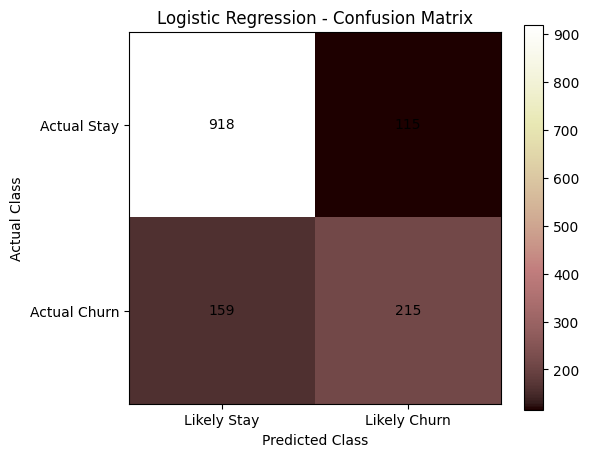

In [37]:
# Create a figure for the confusion matrix
plt.figure(figsize=(6, 5))

# Display the confusion matrix using a pink color map
plt.imshow(cm, cmap="pink")

# Add a color bar to show the intensity
plt.colorbar()

# Add labels for the x-axis
plt.xticks([0, 1], ["Likely Stay", "Likely Churn"])

# Add labels for the y-axis
plt.yticks([0, 1], ["Actual Stay", "Actual Churn"])

# Add the matrix values inside each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# Add the x-axis label
plt.xlabel("Predicted Class")

# Add the y-axis label
plt.ylabel("Actual Class")

# Add the graph title
plt.title("Logistic Regression - Confusion Matrix")

# Display the graph
plt.show()

## 13. Churn Probability Distribution

This visualization shows the distribution of predicted churn probabilities.

Customers with higher probabilities are more likely to require
retention attention.

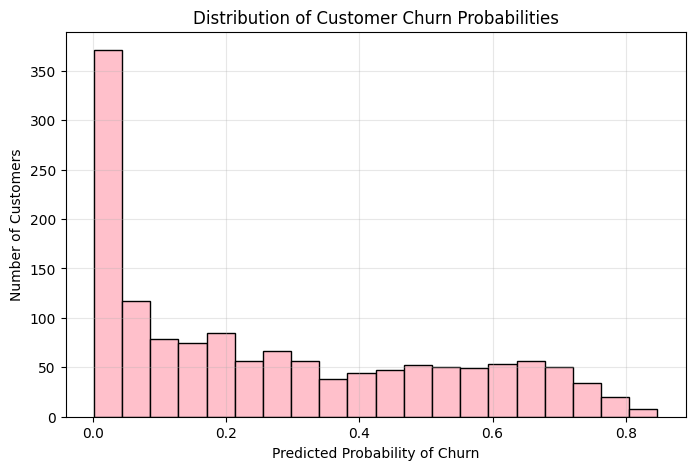

In [38]:
# Create a figure for the probability distribution
plt.figure(figsize=(8, 5))

# Plot the churn probability distribution using pink
plt.hist(churn_probability, bins=20, color="pink", edgecolor="black")

# Add the x-axis label
plt.xlabel("Predicted Probability of Churn")

# Add the y-axis label
plt.ylabel("Number of Customers")

# Add the graph title
plt.title("Distribution of Customer Churn Probabilities")

# Add a grid for easier interpretation
plt.grid(True, alpha=0.3)

# Display the graph
plt.show()

## 14. Classification Report

The classification report provides precision, recall, and F1-score
for both churn and non-churn classes.

In [39]:
# Generate the detailed classification report
report = classification_report(
    y_test,                         # Actual values
    y_pred,                         # Predicted values
    target_names=["Stay", "Churn"]  # Give meaningful class names
)

# Print the classification report
print(report)

              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



## 15. Business Interpretation

The model correctly identified a portion of customers who are likely to churn.

From the confusion matrix:
- True Positives represent customers who were correctly identified as likely to churn.
- False Positives represent loyal customers who were incorrectly flagged as churn.
- False Negatives represent customers who were actually going to churn but were missed.

For a telecom company, missing a customer who is actually going to leave
can be more costly than incorrectly targeting a loyal customer.

Therefore, improving recall for the churn class can be important for
customer retention.

## 16. Business Decision: False Positive vs False Negative

In this business problem, a False Negative is generally more costly.

A False Negative means the model predicts that a customer will stay,
but the customer actually leaves.

The company then loses that customer without having the opportunity
to provide a retention offer.

A False Positive means a loyal customer is incorrectly flagged as likely
to churn. This may result in an unnecessary retention offer or incentive.

Therefore, I would prefer to reduce False Negatives, even if this results
in some additional False Positives.

## 17. Suggested Technical Improvement

One improvement would be to tune the classification threshold.

Instead of always using the default 0.5 probability threshold,
the company could use a lower threshold such as 0.4.

This would allow the model to identify more potential churn customers
and could improve recall.

The threshold should be selected based on the business cost of:
- Missing a customer who churns
- Offering retention incentives to customers who would have stayed

## 18. Conclusion

I used Logistic Regression to predict customer churn using demographic,
service, contract, billing, and customer tenure information.

The model estimates the probability that a customer will churn and
classifies customers into Likely to Churn and Likely to Stay.

The evaluation shows that the model can identify a useful number of
potential churn customers, but some actual churn customers are still missed.

From a business perspective, reducing False Negatives is important because
missing a customer who is going to leave can directly result in lost revenue.

As a next improvement, threshold tuning can be used to increase the model's
ability to identify potential churn customers and support proactive retention.